# Step 7 — BERT Embeddings
**Project:** SDG Mapping for PhD Thesis

**Purpose:** Use contextual BERT embeddings to classify MAHE articles to SDGs

**Inputs:** `data/clean/X_train_bert.csv` · `data/clean/X_test_bert.csv` · `data/clean/mahe_bert.csv`

**Outputs:** `data/results/step7_bert_results.csv` · `data/results/mahe_top5_bert.csv`

> Model: sentence-transformers/all-MiniLM-L6-v2 (fast, 384d, strong performance)

> Pipeline: BERT embeddings → same 4 classifiers → compare vs Steps 4 and 5

> Also: zero-shot BERT similarity directly to SDG profiles (no training needed)

In [1]:
# Cell 1: Install
!pip install sentence-transformers pandas numpy scikit-learn xgboost matplotlib seaborn tqdm torch


   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ------------------------------------ --- 524.3/571.3 kB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 571.3/571.3 kB 3.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/10.6 MB 3.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/10.6 MB 4.1 MB/s eta 0:00:03
   ------- -------------------------------- 2.1/10.6 MB 3.6 MB/s eta 0:00:03
   --------- ------------------------------ 2.6/10.6 MB 3.3 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/10.6 MB 3.2 MB/s eta 0:00:03
   -------------- ------------------------- 3.9/10.6 MB 3.1 MB/s eta 0:00:03
   ----------------- ---------------------- 4.7/10.6 MB 3.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.5/10.6 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 6.3/10.6 MB 3.3 MB/s eta 0:00:02
   ---

In [2]:
# Cell 2: Imports
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from xgboost import XGBClassifier
from IPython.display import display
warnings.filterwarnings('ignore')

CLEAN_DIR   = Path('data/clean')
RESULTS_DIR = Path('data/results')
PLOT_DIR    = Path('data/plots')
MODELS_DIR  = Path('data/models')

with open('data/step2_meta.json') as f:
    meta = json.load(f)
SDG_NAMES = {int(k): v for k, v in meta['sdg_names'].items()}
print('Imports complete')


Imports complete


In [3]:
# Cell 3: Load data
X_train = pd.read_csv(CLEAN_DIR / 'X_train_bert.csv')['text'].fillna('').tolist()
X_test  = pd.read_csv(CLEAN_DIR / 'X_test_bert.csv')['text'].fillna('').tolist()
y_train = pd.read_csv(CLEAN_DIR / 'y_train.csv')['sdg'].tolist()
y_test  = pd.read_csv(CLEAN_DIR / 'y_test.csv')['sdg'].tolist()
mahe    = pd.read_csv(CLEAN_DIR / 'mahe_bert.csv')['text'].fillna('').tolist()
mahe_df = pd.read_csv(CLEAN_DIR / 'mahe_corpus.csv')

classes       = sorted(set(y_train))
label_map     = {sdg: idx for idx, sdg in enumerate(classes)}
label_map_inv = {idx: sdg for sdg, idx in label_map.items()}
y_train_enc   = np.array([label_map[y] for y in y_train])
y_test_enc    = np.array([label_map[y] for y in y_test])

print(f'X_train : {len(X_train):,} samples')
print(f'X_test  : {len(X_test):,}  samples')
print(f'MAHE    : {len(mahe):,}  documents')
print(f'Classes : {len(classes)} SDGs')


X_train : 27,204 samples
X_test  : 6,801  samples
MAHE    : 854  documents
Classes : 16 SDGs


In [5]:
# Cell 4: Load BERT model
# all-MiniLM-L6-v2: fast (80x faster than BERT-base), 384 dimensions
# Strong performance on semantic similarity tasks
# Downloads ~90MB on first run, cached after that
print('Loading sentence-transformers model...')
print('Model: all-MiniLM-L6-v2 (~90MB, downloads once)')
print()
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'Model loaded')
print(f'  Embedding dimensions : 384')
print(f'  Max sequence length  : {model.max_seq_length} tokens')


Loading sentence-transformers model...
Model: all-MiniLM-L6-v2 (~90MB, downloads once)



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded
  Embedding dimensions : 384
  Max sequence length  : 256 tokens


In [6]:
# Cell 5: Encode training and test data
# batch_size=64 balances speed and memory
# show_progress_bar=True shows tqdm progress
print('Encoding training set (27,204 texts)...')
print('This takes 5-15 minutes depending on your CPU/GPU')
print()

X_train_bert = model.encode(
    X_train,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f'\nEncoding test set (6,801 texts)...')
X_test_bert = model.encode(
    X_test,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f'\nBERT embeddings shape:')
print(f'  Train : {X_train_bert.shape}')
print(f'  Test  : {X_test_bert.shape}')

# Save for reuse
np.save(MODELS_DIR / 'X_train_bert.npy', X_train_bert)
np.save(MODELS_DIR / 'X_test_bert.npy',  X_test_bert)
print('Embeddings saved to data/models/')


Encoding training set (27,204 texts)...
This takes 5-15 minutes depending on your CPU/GPU



Batches:   0%|          | 0/426 [00:00<?, ?it/s]


Encoding test set (6,801 texts)...


Batches:   0%|          | 0/107 [00:00<?, ?it/s]


BERT embeddings shape:
  Train : (27204, 384)
  Test  : (6801, 384)
Embeddings saved to data/models/


In [7]:
# Cell 6: Train and evaluate all 4 classifiers on BERT embeddings
classifiers = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced',
        multi_class='multinomial', solver='lbfgs', random_state=42),
    'SVM': CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=42)),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, class_weight='balanced_subsample',
        random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0),
}

bert_results = {}
bert_trained = {}

for name, clf in classifiers.items():
    print(f'Training {name}...')
    if name == 'XGBoost':
        clf.fit(X_train_bert, y_train_enc)
        y_pred_enc = clf.predict(X_test_bert)
        y_pred = np.array([label_map_inv[i] for i in y_pred_enc])
    else:
        clf.fit(X_train_bert, y_train)
        y_pred = clf.predict(X_test_bert)

    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    macro_p  = precision_score(y_test, y_pred, average='macro', zero_division=0)
    macro_r  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    acc      = accuracy_score(y_test, y_pred)

    bert_results[name] = {
        'Macro F1': round(macro_f1, 4),
        'Macro Precision': round(macro_p, 4),
        'Macro Recall': round(macro_r, 4),
        'Accuracy': round(acc, 4),
    }
    bert_trained[name] = clf
    print(f'  Macro F1={macro_f1:.4f}  P={macro_p:.4f}  R={macro_r:.4f}  Acc={acc:.4f}')

print('\nAll BERT classifiers trained')


Training Logistic Regression...
  Macro F1=0.7986  P=0.7953  R=0.8033  Acc=0.8218
Training SVM...
  Macro F1=0.8040  P=0.8083  R=0.8019  Acc=0.8309
Training Random Forest...
  Macro F1=0.7652  P=0.7955  R=0.7570  Acc=0.7990
Training XGBoost...
  Macro F1=0.8004  P=0.8095  R=0.7959  Acc=0.8280

All BERT classifiers trained


In [8]:
# Cell 7: Full comparison across all steps
df_step4 = pd.read_csv(RESULTS_DIR / 'step4_classifier_comparison.csv', index_col=0)
df_step5 = pd.read_csv(RESULTS_DIR / 'step5_embedding_comparison.csv', index_col=0)

# Build unified comparison table
comparison = {}

# TF-IDF (Step 4)
for clf in df_step4.index:
    comparison[f'{clf} + TF-IDF'] = {'Representation': 'TF-IDF', 'Classifier': clf, 'Macro F1': df_step4.loc[clf, 'Macro F1']}

# Best BoW, W2V, GloVe from Step 5
for rep in ['BoW', 'Word2Vec', 'GloVe']:
    subset = df_step5[df_step5['Representation'] == rep]
    if len(subset) > 0:
        best_row = subset.sort_values('Macro F1', ascending=False).iloc[0]
        comparison[f"{best_row['Classifier']} + {rep}"] = {
            'Representation': rep, 'Classifier': best_row['Classifier'],
            'Macro F1': best_row['Macro F1']
        }

# BERT (Step 7)
for clf, metrics in bert_results.items():
    comparison[f'{clf} + BERT'] = {'Representation': 'BERT', 'Classifier': clf, 'Macro F1': metrics['Macro F1']}

df_comparison = pd.DataFrame(comparison).T.sort_values('Macro F1', ascending=False)

print('=' * 65)
print('  FULL COMPARISON — Steps 4, 5, 7')
print('=' * 65)
print(df_comparison[['Representation', 'Classifier', 'Macro F1']].to_string())
print()
best_overall = df_comparison.iloc[0]
print(f"Overall best: {best_overall['Classifier']} + {best_overall['Representation']} -> F1 = {best_overall['Macro F1']:.4f}")

df_comparison.to_csv(RESULTS_DIR / 'step7_bert_results.csv')
print('Saved: data/results/step7_bert_results.csv')


  FULL COMPARISON — Steps 4, 5, 7
                             Representation           Classifier Macro F1
SVM + TF-IDF                         TF-IDF                  SVM   0.8491
Logistic Regression + TF-IDF         TF-IDF  Logistic Regression   0.8284
SVM + BERT                             BERT                  SVM    0.804
XGBoost + TF-IDF                     TF-IDF              XGBoost   0.8036
XGBoost + BERT                         BERT              XGBoost   0.8004
Logistic Regression + BERT             BERT  Logistic Regression   0.7986
XGBoost + BoW                           BoW              XGBoost   0.7981
SVM + GloVe                           GloVe                  SVM   0.7797
Random Forest + BERT                   BERT        Random Forest   0.7652
SVM + Word2Vec                     Word2Vec                  SVM   0.7605
Random Forest + TF-IDF               TF-IDF        Random Forest   0.7546

Overall best: SVM + TF-IDF -> F1 = 0.8491
Saved: data/results/step7_bert_resu

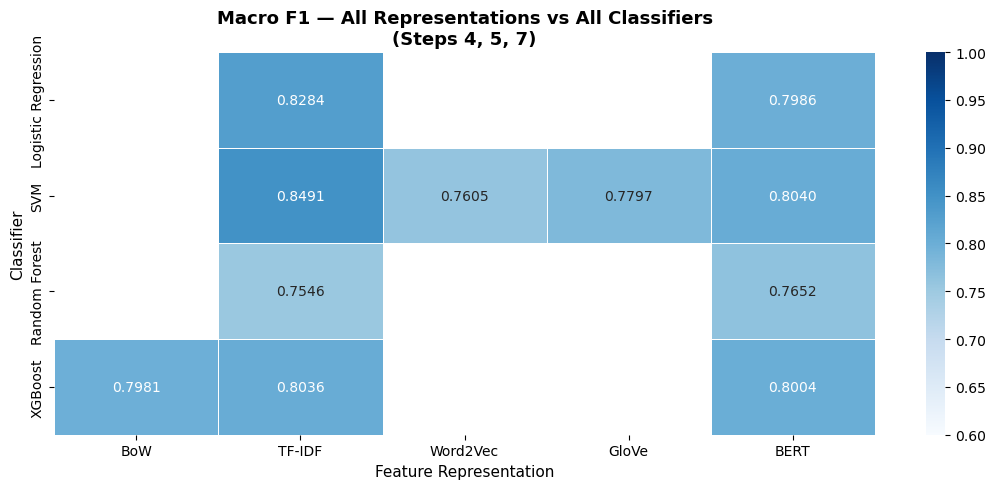

Full comparison heatmap saved


In [9]:
# Cell 8: Comparison heatmap — all representations
reps  = ['BoW', 'TF-IDF', 'Word2Vec', 'GloVe', 'BERT']
clfs  = ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost']

pivot = {}
for rep in reps:
    pivot[rep] = {}
    for clf in clfs:
        key = f'{clf} + {rep}'
        if key in comparison:
            pivot[rep][clf] = comparison[key]['Macro F1']
        else:
            pivot[rep][clf] = np.nan

df_pivot = pd.DataFrame(pivot)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    df_pivot, annot=True, fmt='.4f', cmap='Blues',
    linewidths=0.5, linecolor='white', ax=ax,
    vmin=0.6, vmax=1.0, annot_kws={'size': 10}
)
ax.set_title('Macro F1 — All Representations vs All Classifiers\n(Steps 4, 5, 7)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Representation', fontsize=11)
ax.set_ylabel('Classifier', fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / '12_full_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Full comparison heatmap saved')


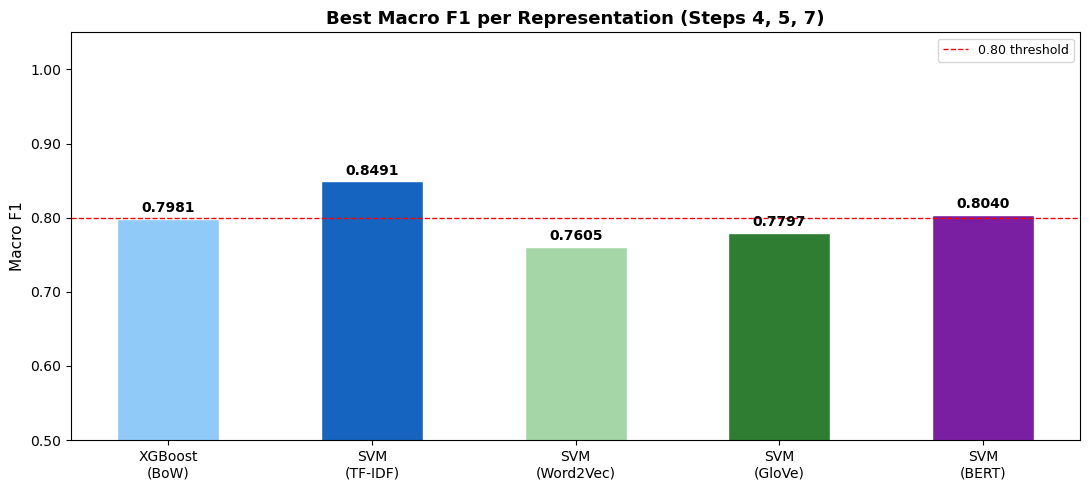

F1 progression chart saved


In [10]:
# Cell 9: F1 progression chart — best per representation
rep_order  = ['BoW', 'TF-IDF', 'Word2Vec', 'GloVe', 'BERT']
best_per_rep = []
for rep in rep_order:
    subset = [(k, v['Macro F1']) for k, v in comparison.items() if v['Representation'] == rep]
    if subset:
        best_per_rep.append(max(subset, key=lambda x: x[1]))
    else:
        best_per_rep.append((rep, 0))

labels = [b[0].split(' + ')[0] + f'\n({r})' for b, r in zip(best_per_rep, rep_order)]
values = [b[1] for b in best_per_rep]
colors = ['#90CAF9', '#1565C0', '#A5D6A7', '#2E7D32', '#7B1FA2']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0.8, color='red', linestyle='--', linewidth=1, label='0.80 threshold')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_title('Best Macro F1 per Representation (Steps 4, 5, 7)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.tight_layout()
plt.savefig(PLOT_DIR / '13_f1_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('F1 progression chart saved')


In [11]:
# Cell 10: Encode MAHE corpus with BERT
print(f'Encoding {len(mahe):,} MAHE articles with BERT...')
X_mahe_bert = model.encode(
    mahe, batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
np.save(MODELS_DIR / 'X_mahe_bert.npy', X_mahe_bert)
print(f'MAHE BERT embeddings shape: {X_mahe_bert.shape}')


Encoding 854 MAHE articles with BERT...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

MAHE BERT embeddings shape: (854, 384)


In [12]:
# Cell 11: Top-5 predictions using best BERT classifier
df_bert = pd.DataFrame(bert_results).T.sort_values('Macro F1', ascending=False)
best_bert_name = df_bert.index[0]
best_bert_clf  = bert_trained[best_bert_name]
print(f'Best BERT classifier: {best_bert_name} (F1={df_bert.iloc[0]["Macro F1"]:.4f})')
print()

if best_bert_name == 'XGBoost':
    proba = best_bert_clf.predict_proba(X_mahe_bert)
    clf_classes = [label_map_inv[i] for i in range(len(classes))]
else:
    proba = best_bert_clf.predict_proba(X_mahe_bert)
    clf_classes = list(best_bert_clf.classes_)

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

bert_mahe_results = []
for i in range(len(mahe)):
    doc_proba  = proba[i]
    sorted_idx = np.argsort(doc_proba)[::-1]
    top5_sdgs   = [int(clf_classes[j]) for j in sorted_idx[:5]]
    top5_scores = [round(float(doc_proba[j]), 4) for j in sorted_idx[:5]]
    top5_names  = [SDG_NAMES.get(s, f'SDG {s}') for s in top5_sdgs]
    top5_soft   = softmax(np.array(top5_scores)).round(4).tolist()
    title = str(mahe_df.iloc[i]['title']) if 'title' in mahe_df.columns else str(mahe_df.iloc[i]['text'])[:80]
    bert_mahe_results.append({
        'Title':         title,
        'Rank1_SDG':     f'SDG {top5_sdgs[0]}', 'Rank1_Name': top5_names[0], 'Rank1_Score': top5_scores[0], 'Rank1_Softmax': top5_soft[0],
        'Rank2_SDG':     f'SDG {top5_sdgs[1]}', 'Rank2_Name': top5_names[1], 'Rank2_Score': top5_scores[1], 'Rank2_Softmax': top5_soft[1],
        'Rank3_SDG':     f'SDG {top5_sdgs[2]}', 'Rank3_Name': top5_names[2], 'Rank3_Score': top5_scores[2], 'Rank3_Softmax': top5_soft[2],
        'Rank4_SDG':     f'SDG {top5_sdgs[3]}', 'Rank4_Name': top5_names[3], 'Rank4_Score': top5_scores[3], 'Rank4_Softmax': top5_soft[3],
        'Rank5_SDG':     f'SDG {top5_sdgs[4]}', 'Rank5_Name': top5_names[4], 'Rank5_Score': top5_scores[4], 'Rank5_Softmax': top5_soft[4],
        'Top5_SDGs':     ', '.join([f'SDG {s}' for s in top5_sdgs]),
        'All_Probs':     ', '.join([f'SDG {int(clf_classes[j])}:{doc_proba[j]:.4f}' for j in sorted_idx]),
    })

df_bert_mahe = pd.DataFrame(bert_mahe_results)
df_bert_mahe.to_csv(RESULTS_DIR / 'mahe_top5_bert.csv', index=False, encoding='utf-8-sig')
print(f'Saved: data/results/mahe_top5_bert.csv')
print()
print('Sample BERT predictions:')
print(df_bert_mahe[['Title','Rank1_SDG','Rank1_Name','Rank1_Score','Top5_SDGs']].head(5).to_string())


Best BERT classifier: SVM (F1=0.8040)

Saved: data/results/mahe_top5_bert.csv

Sample BERT predictions:
                                                                                                                 Title Rank1_SDG                              Rank1_Name  Rank1_Score                              Top5_SDGs
0                 Analytical and bioanalytical HPLC method for simultaneous estimation of 5-fluorouracil and sonidegib    SDG 16  Peace, Justice and Strong Institutions       0.5180    SDG 16, SDG 3, SDG 11, SDG 8, SDG 6
1                           ‘Solving’ as a key course learning outcome (CLO) in postgraduate (PG) management education     SDG 4                       Quality Education       0.6851    SDG 4, SDG 16, SDG 7, SDG 14, SDG 5
2                 Remote Sensing: A Satellite-Based Advanced Geospatial Technology Boon in Natural Resource Management    SDG 15                            Life on Land       0.7078  SDG 15, SDG 13, SDG 9, SDG 16, SDG 14
3  Spatial c

In [13]:
# Cell 12: BERT zero-shot similarity on SDG profiles
# Encode SDG profiles with same BERT model for direct cosine similarity
print('BERT zero-shot: encoding SDG profiles...')

SDG_PROFILE_TEXTS = {
    1:  'End poverty all forms everywhere eradicate extreme poverty social protection poor vulnerable equal rights economic resources ownership',
    2:  'End hunger achieve food security improved nutrition sustainable agriculture malnutrition stunting crop yield smallholder farming',
    3:  'Ensure healthy lives promote wellbeing reduce maternal mortality end epidemics AIDS tuberculosis malaria universal health coverage vaccines mental health',
    4:  'Ensure inclusive equitable quality education lifelong learning literacy numeracy skills teachers school curriculum vocational training',
    5:  'Achieve gender equality empower women girls end discrimination violence empowerment sexual reproductive rights leadership',
    6:  'Ensure availability sustainable management water sanitation drinking water hygiene wastewater treatment groundwater quality',
    7:  'Ensure access affordable reliable sustainable modern energy electricity renewable solar wind hydropower energy efficiency',
    8:  'Promote sustained inclusive sustainable economic growth full productive employment decent work GDP productivity labour market',
    9:  'Build resilient infrastructure promote inclusive sustainable industrialization foster innovation technology research development',
    10: 'Reduce inequality within among countries social inclusion equal opportunity migration refugee discrimination wealth gap',
    11: 'Make cities human settlements inclusive safe resilient sustainable housing transport urban planning disaster risk air quality',
    12: 'Ensure sustainable consumption production patterns recycling waste management circular economy food waste corporate sustainability',
    13: 'Take urgent action combat climate change greenhouse gas emissions carbon neutrality net zero Paris agreement adaptation resilience',
    14: 'Conserve sustainably use oceans seas marine resources pollution coral reef fishery ocean acidification biodiversity',
    15: 'Protect restore sustainable use terrestrial ecosystems forests biodiversity land degradation deforestation wetlands conservation',
    16: 'Promote peaceful inclusive societies access justice rule of law corruption governance democracy human rights institutions',
    17: 'Strengthen means implementation global partnership sustainable development official development assistance technology transfer capacity building trade',
}

sdg_ids_bert   = sorted(SDG_PROFILE_TEXTS.keys())
sdg_texts_bert = [SDG_PROFILE_TEXTS[s] for s in sdg_ids_bert]
sdg_bert_vecs  = model.encode(sdg_texts_bert, convert_to_numpy=True)
sdg_bert_norm  = normalize(sdg_bert_vecs)
mahe_bert_norm = normalize(X_mahe_bert)

bert_sim_matrix = cosine_similarity(mahe_bert_norm, sdg_bert_norm)
print(f'BERT zero-shot similarity matrix: {bert_sim_matrix.shape}')

# Generate top-5 from BERT zero-shot
bert_zs_results = []
for i in range(len(mahe)):
    raw  = bert_sim_matrix[i]
    soft = softmax(raw)
    idx  = np.argsort(raw)[::-1]
    top5 = [sdg_ids_bert[j] for j in idx[:5]]
    cos5 = [round(float(raw[j]),  4) for j in idx[:5]]
    sf5  = [round(float(soft[j]), 4) for j in idx[:5]]
    nm5  = [SDG_NAMES.get(s, '') for s in top5]
    title = str(mahe_df.iloc[i]['title']) if 'title' in mahe_df.columns else str(mahe_df.iloc[i]['text'])[:80]
    bert_zs_results.append({
        'Title':      title,
        'Rank1_SDG':  f'SDG {top5[0]}', 'Rank1_Name': nm5[0], 'Rank1_Cosine': cos5[0], 'Rank1_Softmax': sf5[0],
        'Rank2_SDG':  f'SDG {top5[1]}', 'Rank2_Name': nm5[1], 'Rank2_Cosine': cos5[1],
        'Rank3_SDG':  f'SDG {top5[2]}', 'Rank3_Name': nm5[2], 'Rank3_Cosine': cos5[2],
        'Rank4_SDG':  f'SDG {top5[3]}', 'Rank4_Name': nm5[3], 'Rank4_Cosine': cos5[3],
        'Rank5_SDG':  f'SDG {top5[4]}', 'Rank5_Name': nm5[4], 'Rank5_Cosine': cos5[4],
        'Top5_SDGs':  ', '.join([f'SDG {s}' for s in top5]),
    })

df_bert_zs = pd.DataFrame(bert_zs_results)
df_bert_zs.to_csv(RESULTS_DIR / 'mahe_top5_bert_zerosshot.csv', index=False, encoding='utf-8-sig')
print(f'Saved: data/results/mahe_top5_bert_zerosshot.csv')
print()
print('Sample BERT zero-shot predictions:')
print(df_bert_zs[['Title','Rank1_SDG','Rank1_Name','Rank1_Cosine']].head(5).to_string())


BERT zero-shot: encoding SDG profiles...
BERT zero-shot similarity matrix: (854, 17)
Saved: data/results/mahe_top5_bert_zerosshot.csv

Sample BERT zero-shot predictions:
                                                                                                                 Title Rank1_SDG                              Rank1_Name  Rank1_Cosine
0                 Analytical and bioanalytical HPLC method for simultaneous estimation of 5-fluorouracil and sonidegib    SDG 14                        Life Below Water       -0.0065
1                           ‘Solving’ as a key course learning outcome (CLO) in postgraduate (PG) management education     SDG 4                       Quality Education        0.2819
2                 Remote Sensing: A Satellite-Based Advanced Geospatial Technology Boon in Natural Resource Management    SDG 15                            Life on Land        0.3123
3  Spatial circularity in sustainable urban development: a scoping review of the spatial dimension

In [14]:
# Cell 13: Step 7 summary
tfidf_best = df_step4['Macro F1'].max()
bert_best  = df_bert.iloc[0]['Macro F1']
improvement = bert_best - tfidf_best

print('=' * 62)
print('  STEP 7 - BERT EMBEDDINGS SUMMARY')
print('=' * 62)
print()
print('  Model: sentence-transformers/all-MiniLM-L6-v2')
print('  Dimensions: 384 | Max tokens: 256')
print()
print('  BERT classifier results (Macro F1):')
for clf_name, row in df_bert.iterrows():
    marker = ' <- best' if clf_name == best_bert_name else ''
    print(f'    {clf_name:<25} : {row["Macro F1"]:.4f}{marker}')
print()
diff_str = f'+{improvement:.4f}' if improvement >= 0 else f'{improvement:.4f}'
print(f'  Step 4 TF-IDF best : {tfidf_best:.4f} (SVM)')
print(f'  Step 7 BERT best   : {bert_best:.4f} ({best_bert_name})')
print(f'  Change vs TF-IDF   : {diff_str}')
print()
if improvement > 0:
    print('  BERT improved over TF-IDF baseline')
    print('  Contextual embeddings capture semantic meaning beyond keywords')
elif improvement > -0.01:
    print('  BERT performance similar to TF-IDF')
    print('  Both are strong — ensemble in Step 8 will combine them')
else:
    print('  TF-IDF still best — common for short domain-specific texts')
    print('  Fine-tuning BERT on SDG data would likely close this gap')
print()
print('  Output files:')
print('    mahe_top5_bert.csv           - BERT classifier top-5')
print('    mahe_top5_bert_zerosshot.csv - BERT zero-shot similarity top-5')
print('    step7_bert_results.csv       - full comparison all steps')
print()
print('  Plots saved:')
print('    12_full_comparison_heatmap.png')
print('    13_f1_progression.png')
print()
print('Step 7 complete -> next: step8_clustering_evaluation.ipynb')
print('=' * 62)


  STEP 7 - BERT EMBEDDINGS SUMMARY

  Model: sentence-transformers/all-MiniLM-L6-v2
  Dimensions: 384 | Max tokens: 256

  BERT classifier results (Macro F1):
    SVM                       : 0.8040 <- best
    XGBoost                   : 0.8004
    Logistic Regression       : 0.7986
    Random Forest             : 0.7652

  Step 4 TF-IDF best : 0.8491 (SVM)
  Step 7 BERT best   : 0.8040 (SVM)
  Change vs TF-IDF   : -0.0451

  TF-IDF still best — common for short domain-specific texts
  Fine-tuning BERT on SDG data would likely close this gap

  Output files:
    mahe_top5_bert.csv           - BERT classifier top-5
    mahe_top5_bert_zerosshot.csv - BERT zero-shot similarity top-5
    step7_bert_results.csv       - full comparison all steps

  Plots saved:
    12_full_comparison_heatmap.png
    13_f1_progression.png

Step 7 complete -> next: step8_clustering_evaluation.ipynb
